# Batch Scoring Service

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/batch-scorer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/batch-scorer/demo.ipynb)

> Scoring new data shouldn't be a manual copy-paste ritual.

This notebook is **standalone** - it duplicates the core logic so it runs without importing `scorer.py`.

## Contents
1. [Setup & core logic](#setup)
2. [Train the model](#train)
3. [Persist & load the model](#persist)
4. [Score fresh, unlabeled data](#score)
5. [Visualize the results](#viz)
6. [Try your own data](#try)


<a id="setup"></a>
## 1. Setup & core logic

We define the feature schema and the scoring helpers inline so the notebook is self-contained.

In [1]:
from __future__ import annotations

from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

FEATURE_NAMES: List[str] = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets",
    "avg_session_minutes",
    "days_since_last_login",
    "num_features_used",
    "contract_length_months",
]
DEFAULT_THRESHOLD: float = 0.5


def make_dataset(n_samples: int, seed: int) -> pd.DataFrame:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=len(FEATURE_NAMES),
        n_informative=5,
        n_redundant=1,
        n_clusters_per_class=2,
        weights=[0.72, 0.28],
        random_state=seed,
    )
    df = pd.DataFrame(X, columns=FEATURE_NAMES)
    df["churned"] = y
    return df


def score_frame(bundle: Dict[str, object], df: pd.DataFrame) -> pd.DataFrame:
    model = bundle["model"]
    feature_names: List[str] = list(bundle["feature_names"])
    threshold: float = float(bundle.get("threshold", DEFAULT_THRESHOLD))
    missing = [c for c in feature_names if c not in set(df.columns)]
    if missing:
        raise ValueError(
            "Input is missing required feature column(s): " + ", ".join(missing)
        )
    X = df[feature_names].copy()  # drop extras, reorder to schema
    result = df.copy()
    if len(X) == 0:
        result["score"] = pd.Series(dtype="float64")
        result["prediction"] = pd.Series(dtype="int64")
        return result
    proba = model.predict_proba(X)[:, 1]
    result["score"] = proba
    result["prediction"] = (proba >= threshold).astype(int)
    return result


def sample_new_data(n: int = 200, seed: int = 7) -> pd.DataFrame:
    return make_dataset(n_samples=n, seed=seed)[FEATURE_NAMES].copy()

print("Core logic ready. Feature schema:")
for f in FEATURE_NAMES:
    print("  -", f)


Core logic ready. Feature schema:
  - tenure_months
  - monthly_charges
  - total_charges
  - num_support_tickets
  - avg_session_minutes
  - days_since_last_login
  - num_features_used
  - contract_length_months


<a id="train"></a>
## 2. Train the model

We train a `RandomForestClassifier` on a synthetic churn-style dataset.

In [2]:
train_df = make_dataset(n_samples=2000, seed=42)
X_train = train_df[FEATURE_NAMES]
y_train = train_df["churned"]

model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print(f"Trained on {len(train_df)} rows. Base churn rate: {y_train.mean():.1%}")


Trained on 2000 rows. Base churn rate: 28.0%


<a id="persist"></a>
## 3. Persist & load the model

We save the model, its feature schema, and the threshold as one `joblib` bundle - then load it back, exactly as a production job would.

In [3]:
bundle = {
    "model": model,
    "feature_names": list(FEATURE_NAMES),
    "threshold": DEFAULT_THRESHOLD,
}
joblib.dump(bundle, "model.joblib")
loaded = joblib.load("model.joblib")
print("Bundle persisted and reloaded.")
print("Keys:", list(loaded.keys()))
print("Threshold:", loaded["threshold"])


Bundle persisted and reloaded.
Keys: ['model', 'feature_names', 'threshold']
Threshold: 0.5


<a id="score"></a>
## 4. Score fresh, unlabeled data

Here is the payoff: fresh rows with **no labels** come in, and we get a probability `score` plus a 0/1 `prediction` back.

In [4]:
new_data = sample_new_data(n=200, seed=7)
print("Incoming unlabeled rows:", new_data.shape)

scored = score_frame(loaded, new_data)
n_rows = len(scored)
n_flagged = int(scored["prediction"].sum())
positive_rate = n_flagged / n_rows
print(f"Rows scored:   {n_rows}")
print(f"Rows flagged:  {n_flagged}")
print(f"Positive rate: {positive_rate:.1%}")

scored[FEATURE_NAMES[:3] + ["score", "prediction"]].head(10)


Incoming unlabeled rows: (200, 8)
Rows scored:   200
Rows flagged:  64
Positive rate: 32.0%


,tenure_months,monthly_charges,total_charges,score,prediction
0,-1.992679,0.466775,0.103721,0.651574,1
1,2.184859,-0.071332,-0.418846,0.302798,0
2,-1.775517,0.161734,0.710268,0.222318,0
3,-1.205305,1.605075,0.017704,0.272118,0
4,0.365114,2.154930,-0.905468,0.611005,1
5,-0.089331,-0.569359,-0.737925,0.423395,0
6,-3.157209,0.117039,0.734976,0.463891,0
7,-0.866760,0.040519,1.722606,0.137651,0
8,0.907337,-0.166558,1.157038,0.416191,0
9,-1.840356,1.215857,0.821306,0.233111,0


<a id="viz"></a>
## 5. Visualize the results

A histogram of predicted scores and a bar of flagged vs not-flagged.

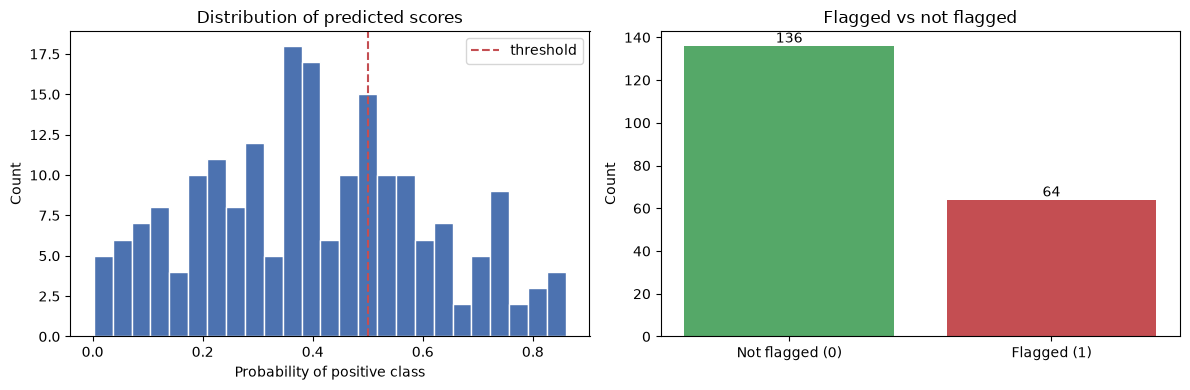

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of predicted scores
axes[0].hist(scored["score"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].axvline(loaded["threshold"], color="#C44E52", linestyle="--", label="threshold")
axes[0].set_title("Distribution of predicted scores")
axes[0].set_xlabel("Probability of positive class")
axes[0].set_ylabel("Count")
axes[0].legend()

# Bar of flagged vs not
counts = scored["prediction"].value_counts().sort_index()
labels = ["Not flagged (0)", "Flagged (1)"]
values = [int(counts.get(0, 0)), int(counts.get(1, 0))]
axes[1].bar(labels, values, color=["#55A868", "#C44E52"])
axes[1].set_title("Flagged vs not flagged")
axes[1].set_ylabel("Count")
for i, v in enumerate(values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

fig.tight_layout()
plt.show()


<a id="try"></a>
## 6. Try your own data

Uncomment and point it at your own CSV - as long as it has the feature columns above, it just works. Extra columns are dropped and reordered automatically; missing ones raise a clear error.

In [6]:
# your_df = pd.read_csv('your_data.csv')
# your_scored = score_frame(loaded, your_df)
# your_scored.to_csv('scored_output.csv', index=False)
# your_scored.head()


---
Built by Phoebe Fu as part of the FDE portfolio - [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
